In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

pd.set_option('display.max_columns', None)

generated = Path('generated')

df_2022 = pd.read_parquet(generated / 'flights_2022_con_climas.parquet')

In [3]:
print(df_2022.shape)
display(df_2022)

(154586, 37)


,fecha_vuelo,aerolinea,aerolinea_dot,codigo_aerolinea,codigo_dot,numero_vuelo,origen,ciudad_origen,destino,ciudad_destino,hora_salida_programada,hora_salida_real,retraso_salida,tiempo_rodaje_salida,despegue,aterrizaje,tiempo_rodaje_llegada,hora_llegada_programada,hora_llegada_real,retraso_llegada,cancelado,codigo_cancelacion,desviado,duracion_programada,duracion_real,tiempo_en_aire,distancia,retraso_por_aerolinea,retraso_por_clima,retraso_por_trafico_aereo,retraso_por_seguridad,retraso_por_avion_tardio,mes,retrasado,temperatura_media,precipitacion,viento_max
0,2022-01-11,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,76,JFK,"New York, NY",SFO,"San Francisco, CA",700,651.0,-9.0,16.0,707.0,954.0,5.0,1053,959.0,-54.0,0.0,None,0.0,413.0,368.0,347.0,2586.0,NaN,NaN,NaN,NaN,NaN,1,0,-6.9,0.0,31.5
1,2022-01-11,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2883,ATL,"Atlanta, GA",GSP,"Greer, SC",1215,1210.0,-5.0,12.0,1222.0,1248.0,4.0,1308,1252.0,-16.0,0.0,None,0.0,53.0,42.0,26.0,153.0,NaN,NaN,NaN,NaN,NaN,1,0,3.1,0.0,23.8
2,2022-01-27,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1337,PHL,"Philadelphia, PA",MCO,"Orlando, FL",1700,1702.0,2.0,10.0,1712.0,1920.0,6.0,1940,1926.0,-14.0,0.0,None,0.0,160.0,144.0,128.0,861.0,NaN,NaN,NaN,NaN,NaN,1,0,-4.6,0.0,12.9
3,2022-01-11,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,4559,DAL,"Dallas, TX",TUL,"Tulsa, OK",1740,1736.0,-4.0,9.0,1745.0,1829.0,5.0,1845,1834.0,-11.0,0.0,None,0.0,65.0,58.0,44.0,238.0,NaN,NaN,NaN,NaN,NaN,1,0,6.5,0.4,18.6
4,2022-01-31,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2552,MSP,"Minneapolis, MN",TPA,"Tampa, FL",1840,1836.0,-4.0,15.0,1851.0,2228.0,5.0,2257,2233.0,-24.0,0.0,None,0.0,197.0,177.0,157.0,1306.0,NaN,NaN,NaN,NaN,NaN,1,0,-7.5,0.0,18.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154581,2022-12-20,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1366,IAD,"Washington, DC",DEN,"Denver, CO",825,824.0,-1.0,18.0,842.0,1009.0,10.0,1025,1019.0,-6.0,0.0,None,0.0,240.0,235.0,207.0,1452.0,NaN,NaN,NaN,NaN,NaN,12,0,-0.9,0.0,12.5
154582,2022-12-12,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1655,CLT,"Charlotte, NC",MKE,"Milwaukee, WI",1140,1136.0,-4.0,20.0,1156.0,1236.0,2.0,1247,1238.0,-9.0,0.0,None,0.0,127.0,122.0,100.0,651.0,NaN,NaN,NaN,NaN,NaN,12,0,7.4,0.0,12.2
154583,2022-12-09,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2254,CHS,"Charleston, SC",DAL,"Dallas, TX",1305,1307.0,2.0,10.0,1317.0,1436.0,3.0,1455,1439.0,-16.0,0.0,None,0.0,170.0,152.0,139.0,977.0,NaN,NaN,NaN,NaN,NaN,12,0,15.8,3.1,14.7
154584,2022-12-16,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1388,DAL,"Dallas, TX",AMA,"Amarillo, TX",835,833.0,-2.0,8.0,841.0,945.0,4.0,950,949.0,-1.0,0.0,None,0.0,75.0,76.0,64.0,323.0,NaN,NaN,NaN,NaN,NaN,12,0,4.8,0.0,17.3


In [4]:
# Los archivos parquet conservan el tipo de dato de cada columna.
df_2022['fecha_vuelo'].dt.day

0         11
1         11
2         27
3         11
4         31
          ..
154581    20
154582    12
154583     9
154584    16
154585    12
Name: fecha_vuelo, Length: 154586, dtype: int32

In [5]:
#Quiero separar en categóricas y numéricas, para poder hacer un análisis más profundo de los datos. 
categorical_columns = df_2022.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df_2022.select_dtypes(include=['int64', 'float64']).columns.tolist()

max_len = max(len(categorical_columns), len(numerical_columns))

columnas_frame = pd.DataFrame({
    'categoricas': categorical_columns + [''] * (max_len - len(categorical_columns)),
    'numericas': numerical_columns + [''] * (max_len - len(numerical_columns))
})

columnas_frame


,categoricas,numericas
0,aerolinea,codigo_dot
1,aerolinea_dot,numero_vuelo
2,codigo_aerolinea,hora_salida_programada
3,origen,hora_salida_real
4,ciudad_origen,retraso_salida
5,destino,tiempo_rodaje_salida
6,ciudad_destino,despegue
7,codigo_cancelacion,aterrizaje
8,,tiempo_rodaje_llegada
9,,hora_llegada_programada


Análisis Outliers

In [6]:
for col in numerical_columns:
    Q1 = df_2022[col].quantile(0.25)
    Q3 = df_2022[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_2022[(df_2022[col] < lower_bound) | (df_2022[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(df_2022)) * 100
    print(f"Column: {col}, Outliers: {len(outliers)}", f"({outlier_percentage:.2f}%)")

Column: codigo_dot, Outliers: 0 (0.00%)
Column: numero_vuelo, Outliers: 44 (0.03%)
Column: hora_salida_programada, Outliers: 0 (0.00%)
Column: hora_salida_real, Outliers: 0 (0.00%)
Column: retraso_salida, Outliers: 17805 (11.52%)
Column: tiempo_rodaje_salida, Outliers: 7889 (5.10%)
Column: despegue, Outliers: 0 (0.00%)
Column: aterrizaje, Outliers: 0 (0.00%)
Column: tiempo_rodaje_llegada, Outliers: 9353 (6.05%)
Column: hora_llegada_programada, Outliers: 0 (0.00%)
Column: hora_llegada_real, Outliers: 0 (0.00%)
Column: retraso_llegada, Outliers: 13608 (8.80%)
Column: cancelado, Outliers: 4098 (2.65%)
Column: desviado, Outliers: 336 (0.22%)
Column: duracion_programada, Outliers: 8279 (5.36%)
Column: duracion_real, Outliers: 7386 (4.78%)
Column: tiempo_en_aire, Outliers: 8121 (5.25%)
Column: distancia, Outliers: 9625 (6.23%)
Column: retraso_por_aerolinea, Outliers: 3109 (2.01%)
Column: retraso_por_clima, Outliers: 1596 (1.03%)
Column: retraso_por_trafico_aereo, Outliers: 2366 (1.53%)
Colum

Las columnas con los outliers más significativos son rafaga_viento y restraso salida

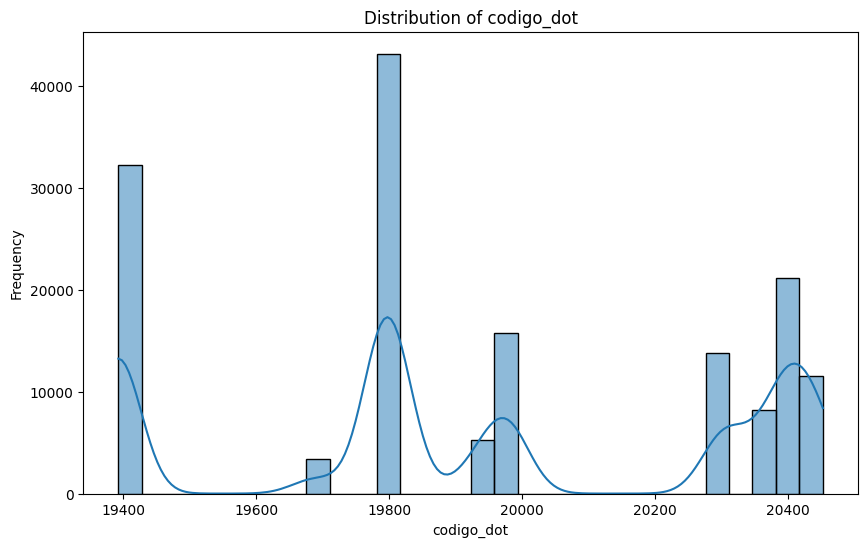

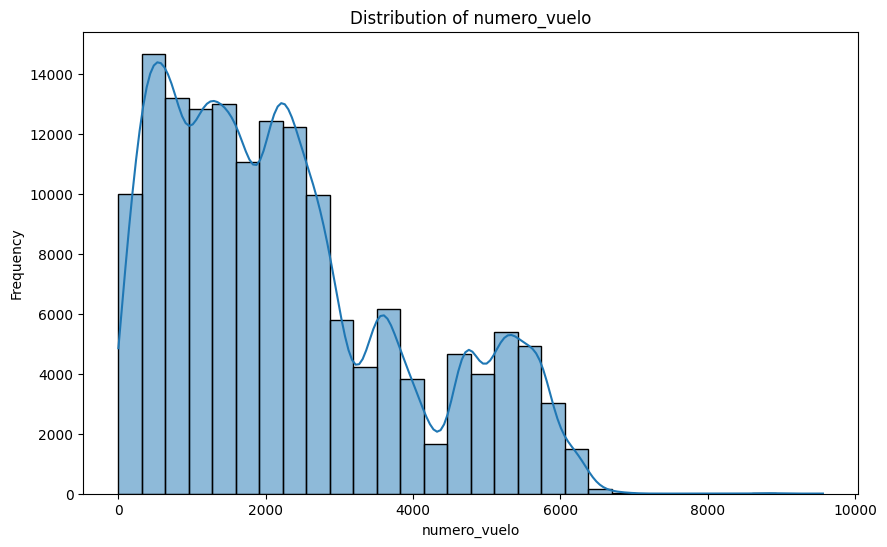

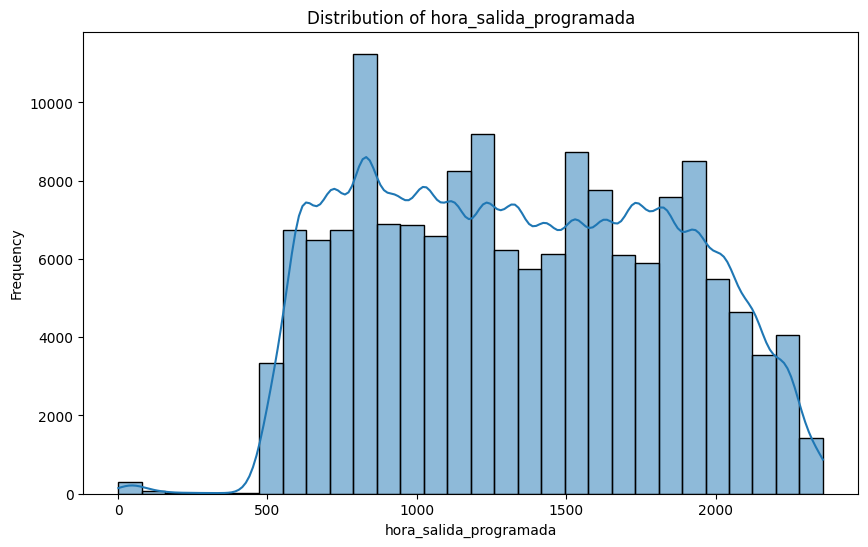

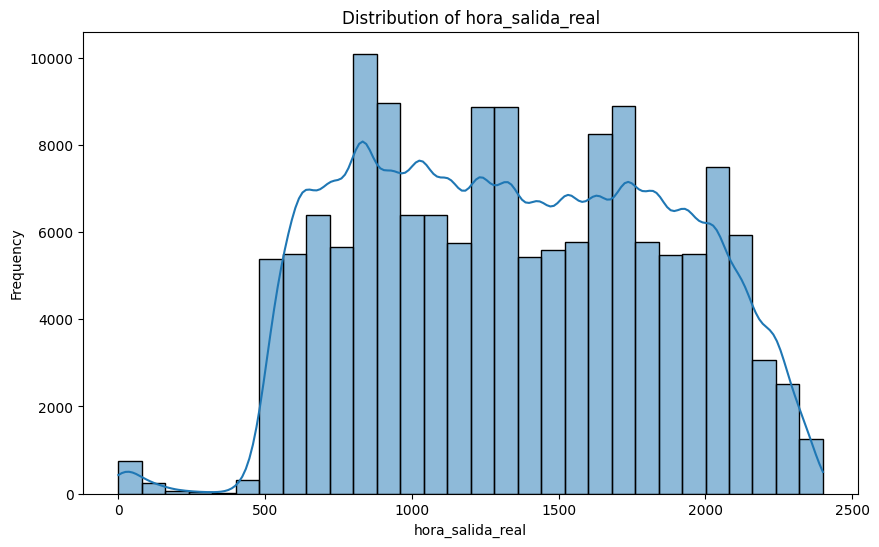

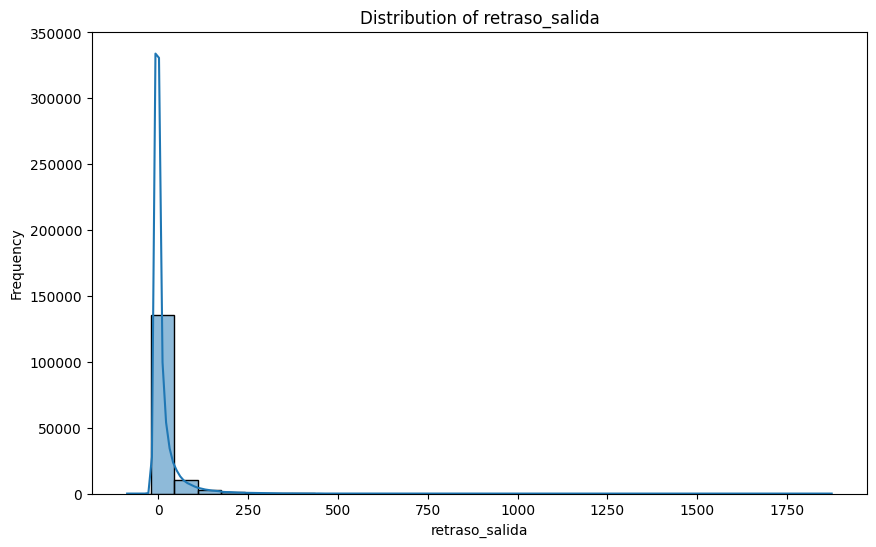

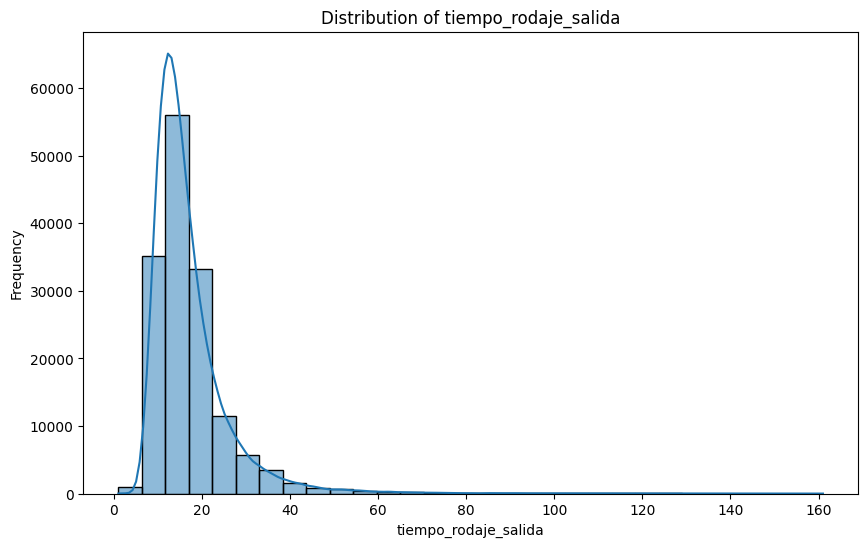

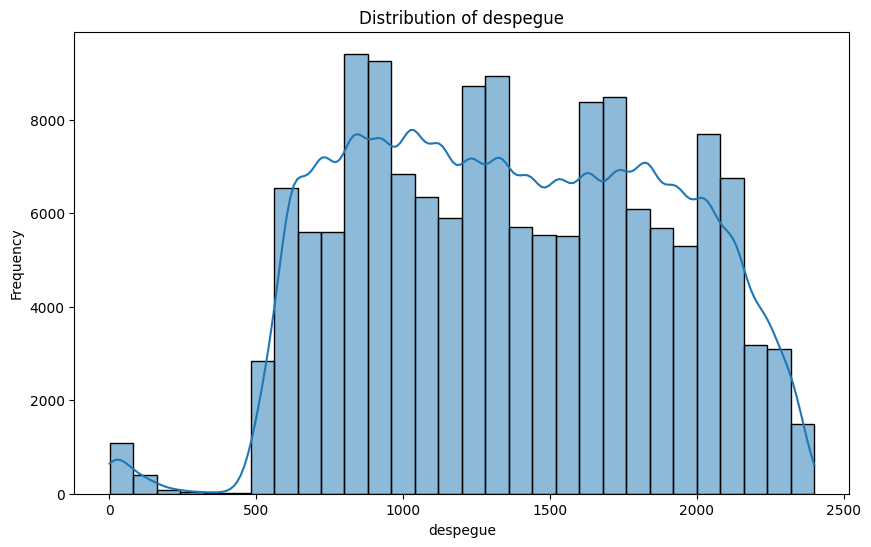

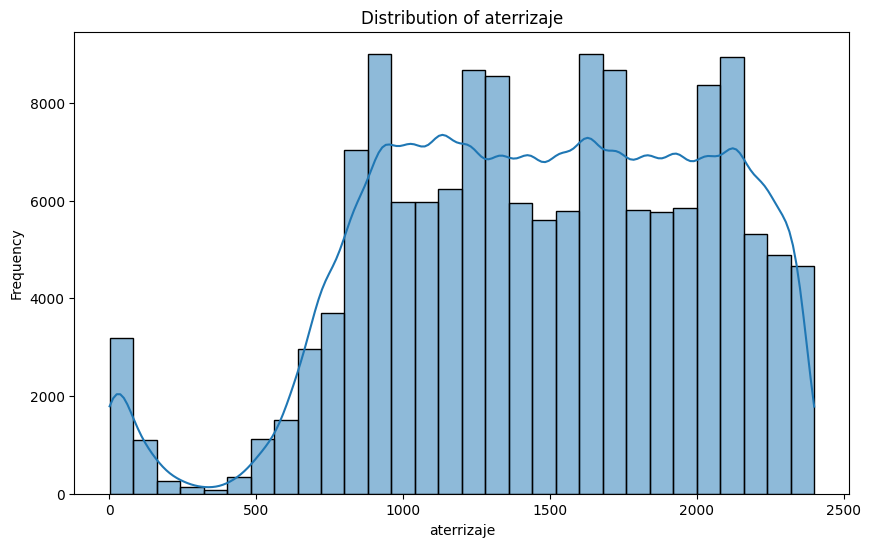

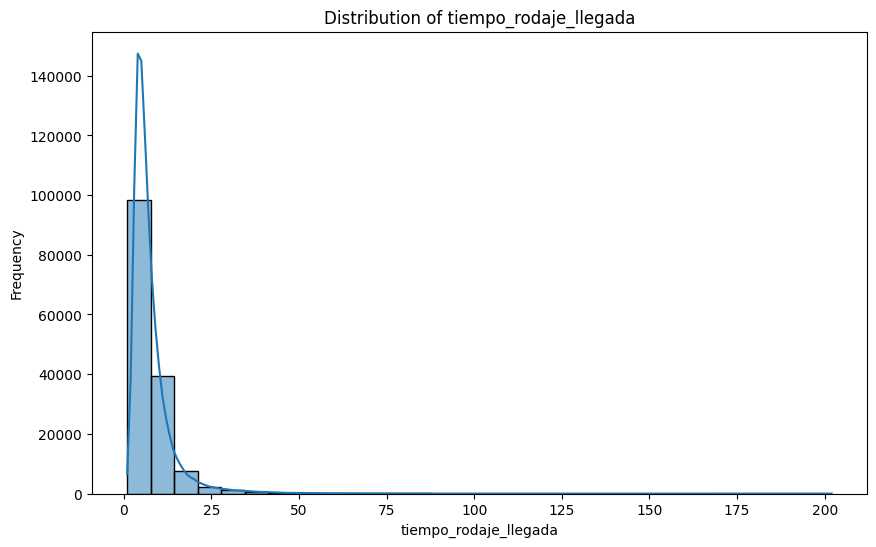

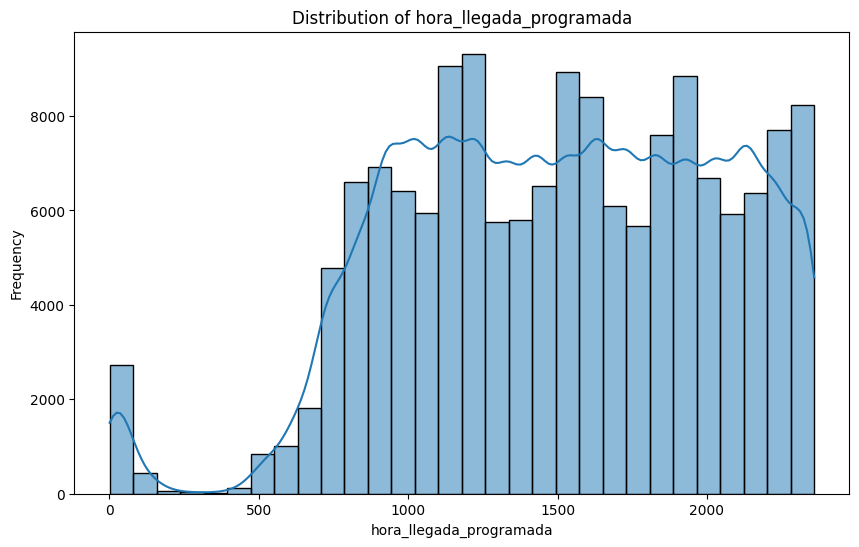

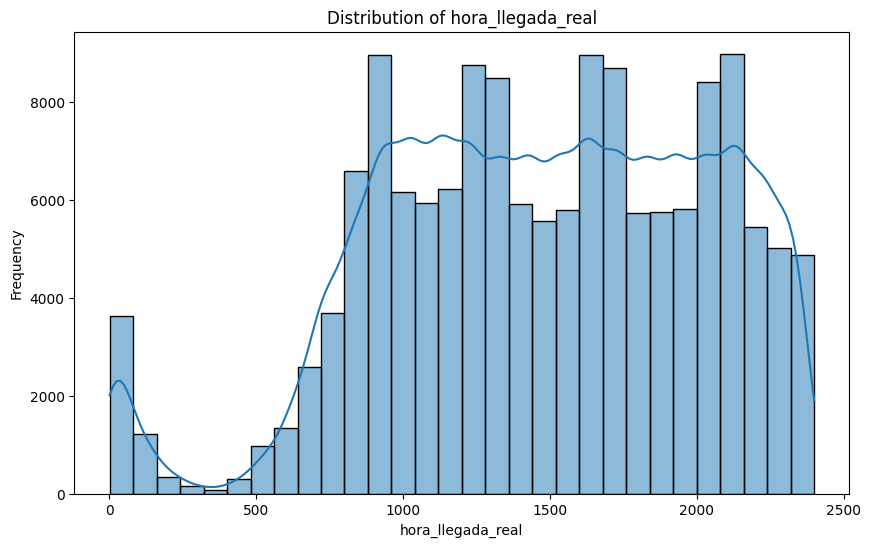

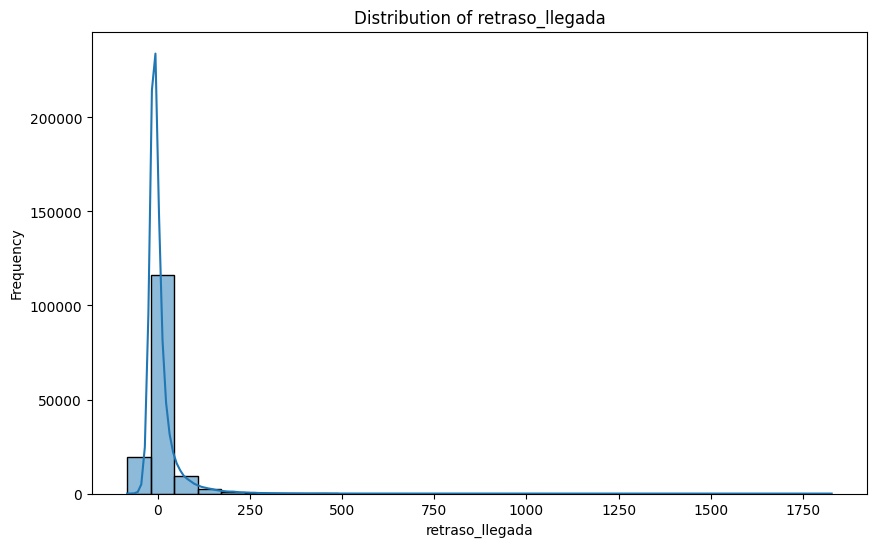

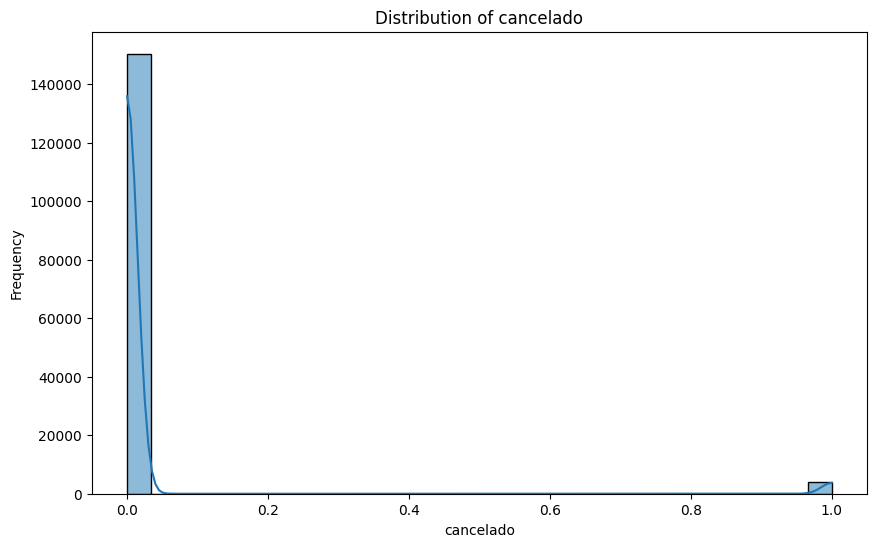

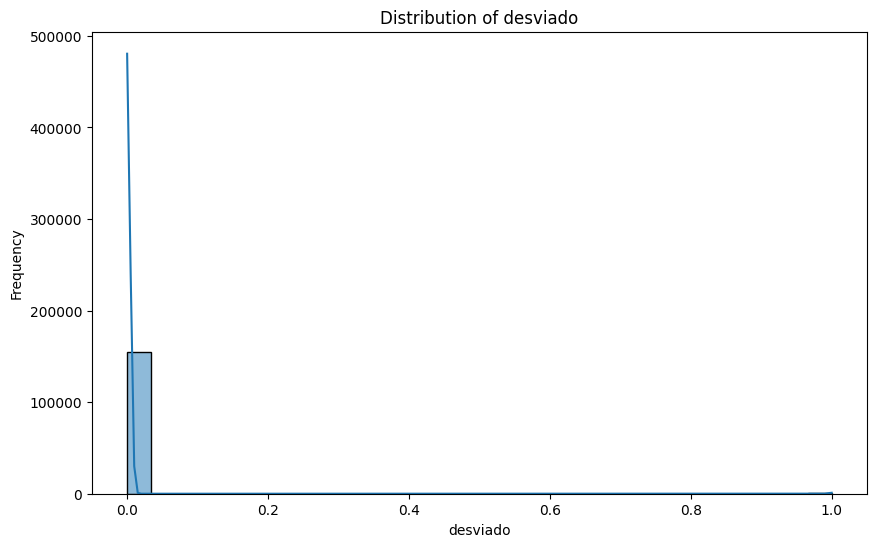

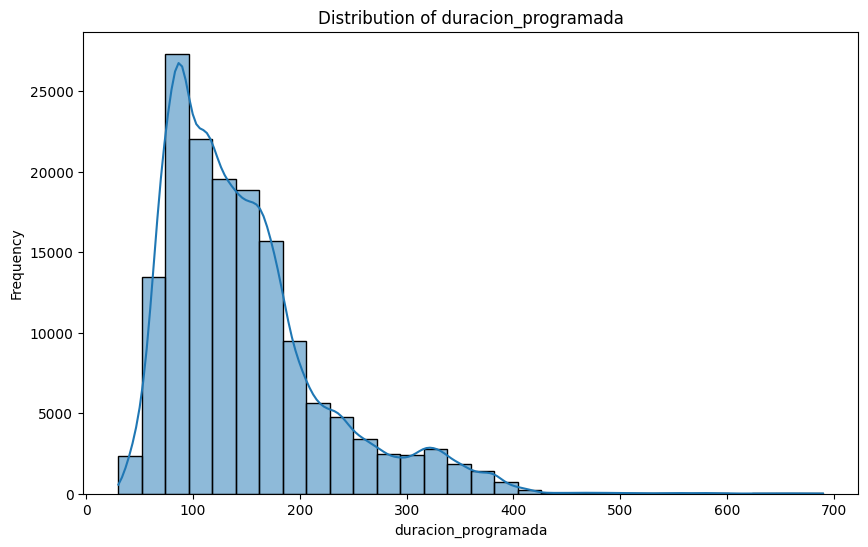

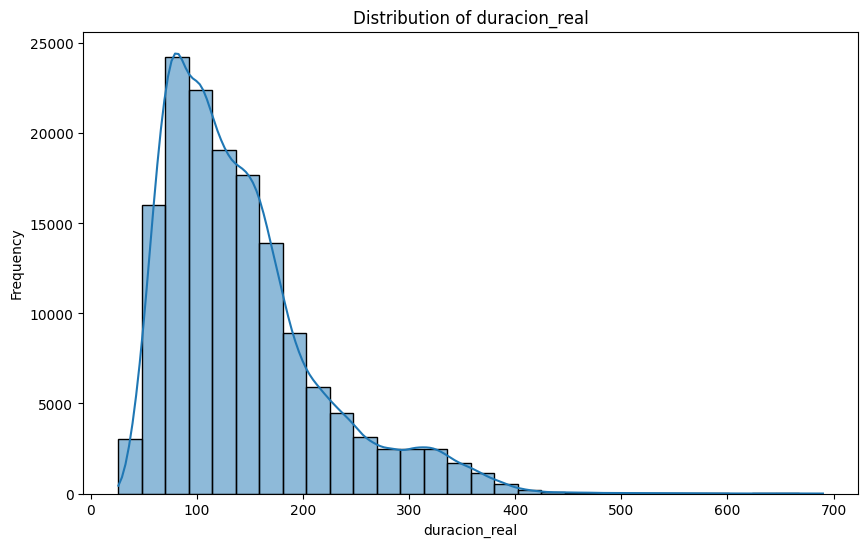

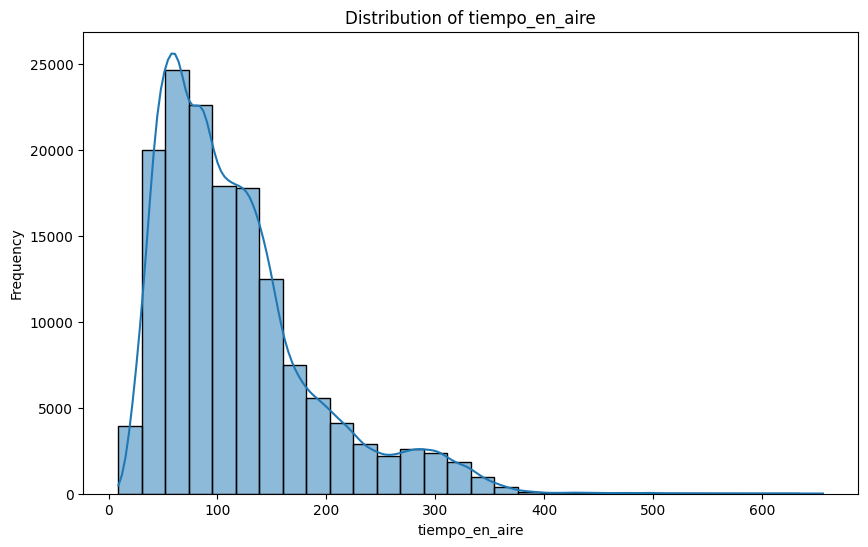

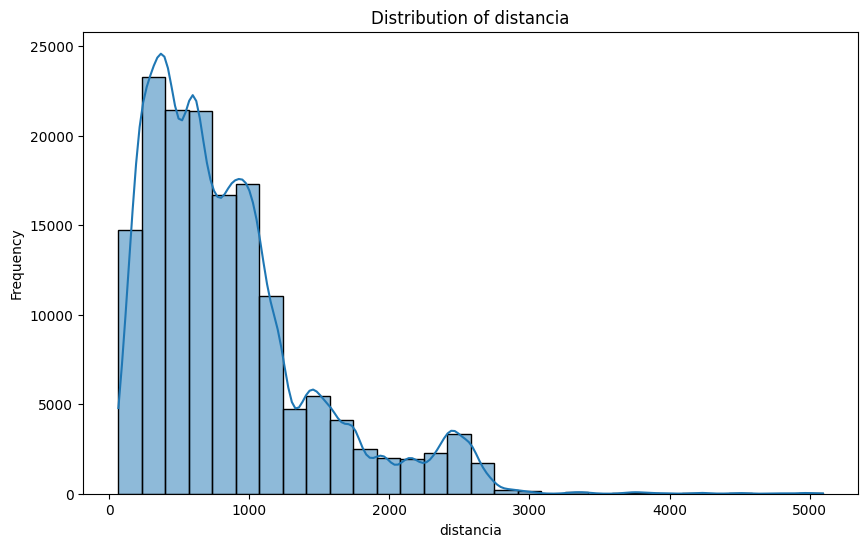

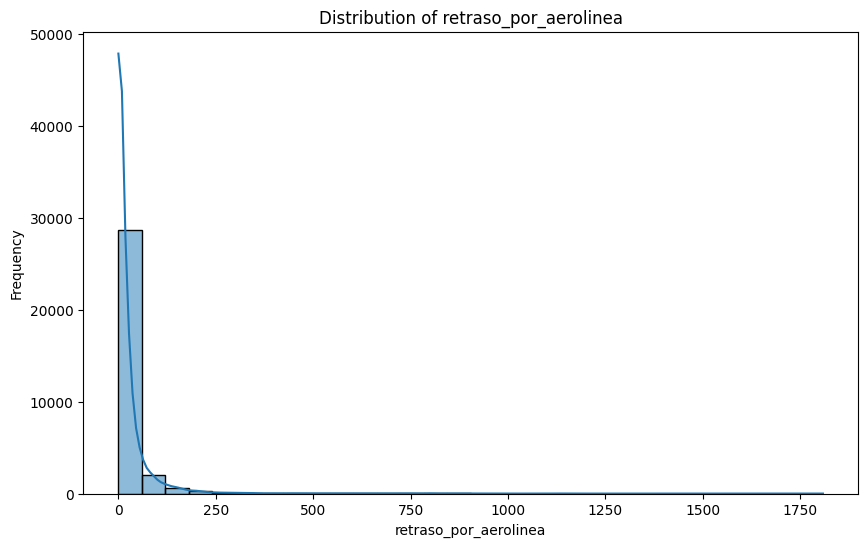

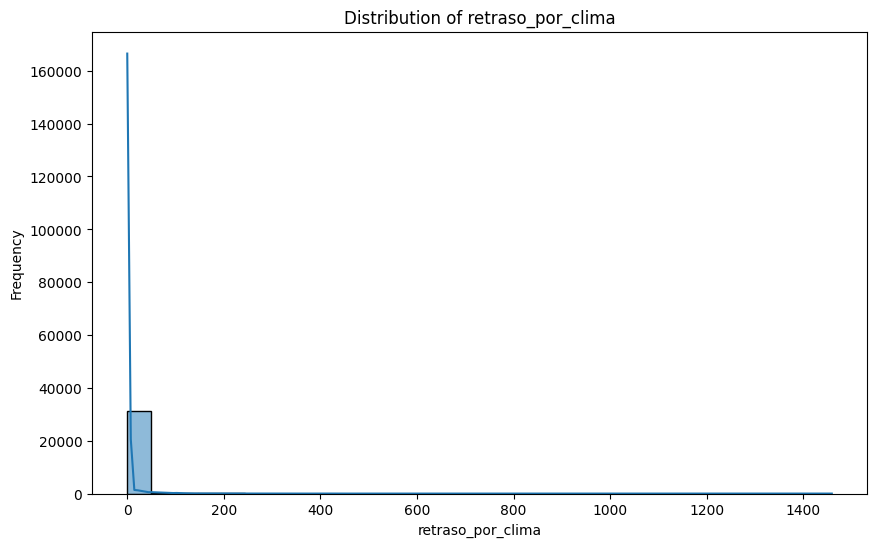

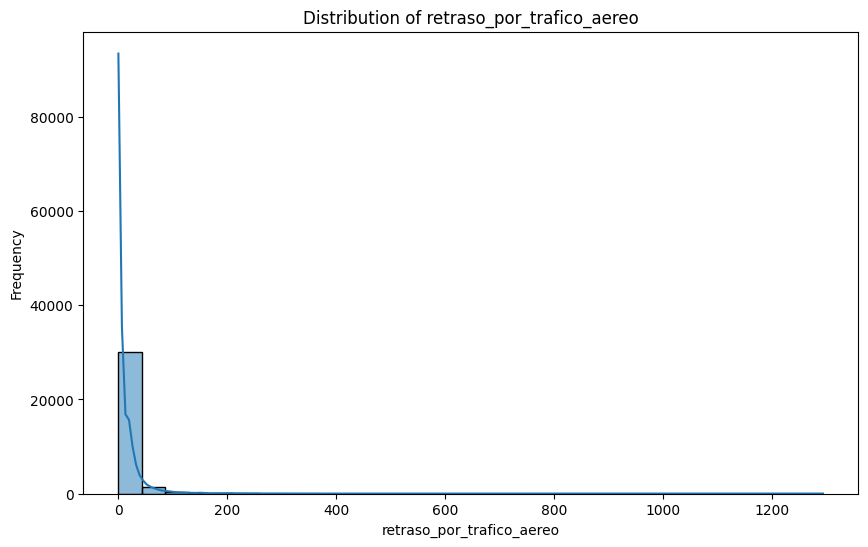

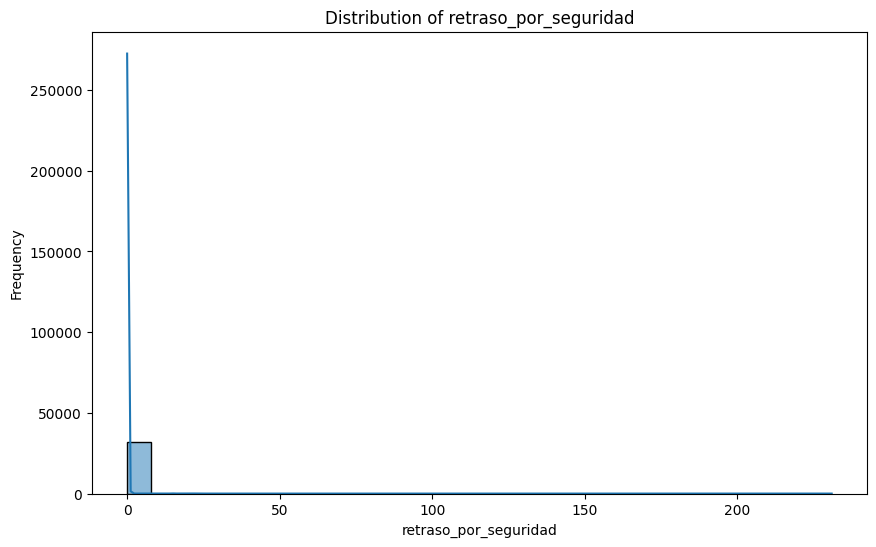

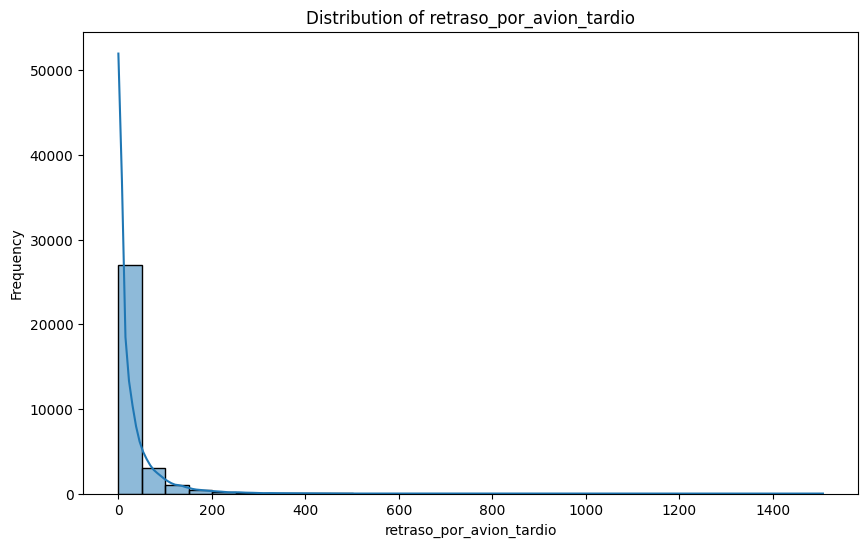

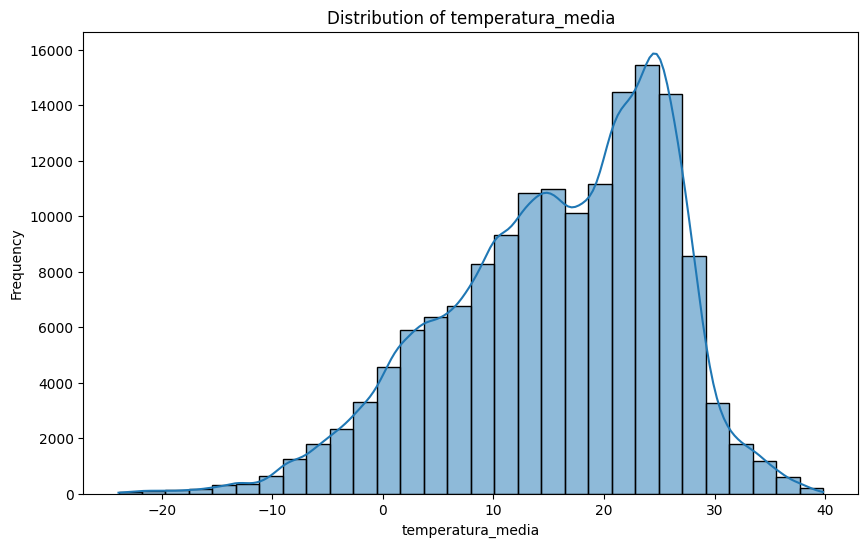

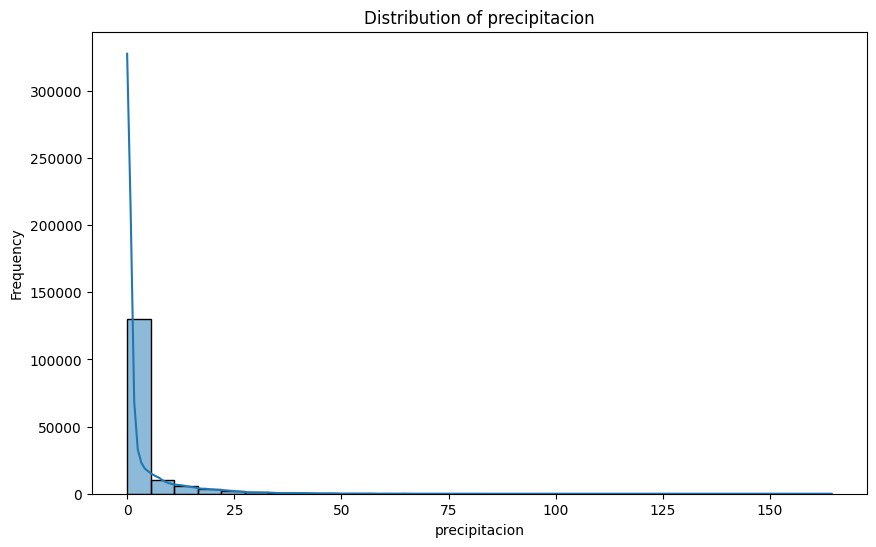

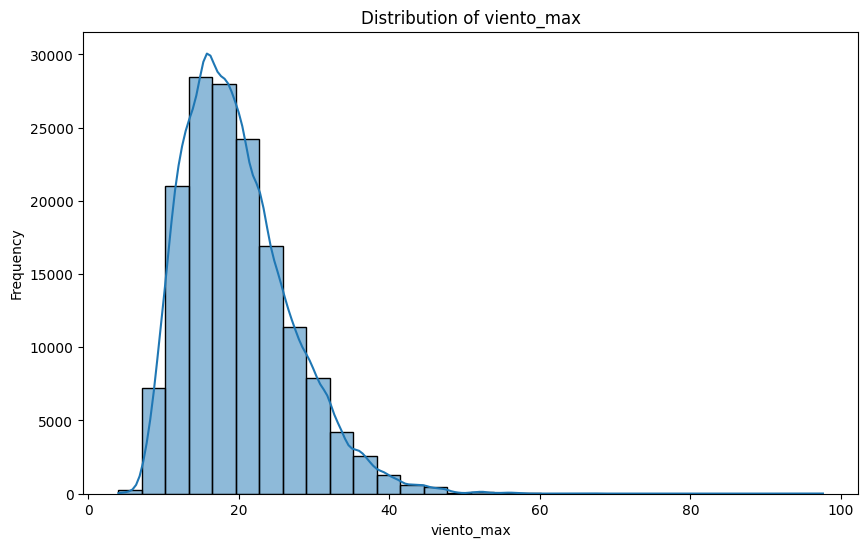

In [7]:
#quiero graficar la distribución de las variables numéricas para ver si hay alguna que tenga una distribución anormal.
for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_2022[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Ánalisis Univariado

In [11]:
#Análisis univariado de las variables categóricas
resumen= pd.DataFrame({
    'Media':df_2022[numerical_columns].mean(), 
    'Mediana':df_2022[numerical_columns].median(),
    'Moda':df_2022[numerical_columns].mode().iloc[0],
    'Desviación Estándar':df_2022[numerical_columns].std(),
    'IQR':df_2022[numerical_columns].quantile(0.75) - df_2022[numerical_columns].quantile(0.25),
    'Skewness':df_2022[numerical_columns].skew()}).round(3)
print('Resumen estadístico de las variables numéricas:')
display(resumen)

Resumen estadístico de las variables numéricas:


,Media,Mediana,Moda,Desviación Estándar,IQR,Skewness
codigo_dot,19940.640,19805.0,19393.0,374.402,573.00,-0.067
numero_vuelo,2295.423,2002.0,772.0,1635.685,2304.75,0.717
hora_salida_programada,1344.282,1328.0,600.0,494.489,828.00,0.086
hora_salida_real,1347.848,1331.0,555.0,509.665,834.00,0.032
retraso_salida,12.645,-1.0,-5.0,51.254,16.00,11.010
tiempo_rodaje_salida,17.027,15.0,12.0,9.161,8.00,3.575
despegue,1368.905,1344.0,611.0,512.424,873.00,-0.011
aterrizaje,1466.910,1505.0,958.0,544.827,875.00,-0.368
tiempo_rodaje_llegada,7.741,6.0,4.0,6.623,5.00,5.445
hora_llegada_programada,1498.314,1521.0,2359.0,525.940,827.00,-0.324


In [8]:
# Conteo absoluto
conteo = df_2022['retrasado'].value_counts()
print("Conteo de vuelos:")
print(conteo)

# Porcentaje
porcentaje = df_2022['retrasado'].value_counts(normalize=True) * 100
print("\nPorcentaje de vuelos:")
print(porcentaje.round(2))

Conteo de vuelos:
retrasado
0    123038
1     31548
Name: count, dtype: int64

Porcentaje de vuelos:
retrasado
0    79.59
1    20.41
Name: proportion, dtype: float64


Por lo que podemos ver en esta parte del código podríamos decir que existe un desbalanceo de clases ya que el 20% del dataset son vuelos con retrasos y el otro 80% son vuelos que salieron a tiempo. Por lo que, a la hora de entrenar el modelo no deberíamos mirar únicamente el accuracy y además vamos a tener que realizar un balanceo de clases

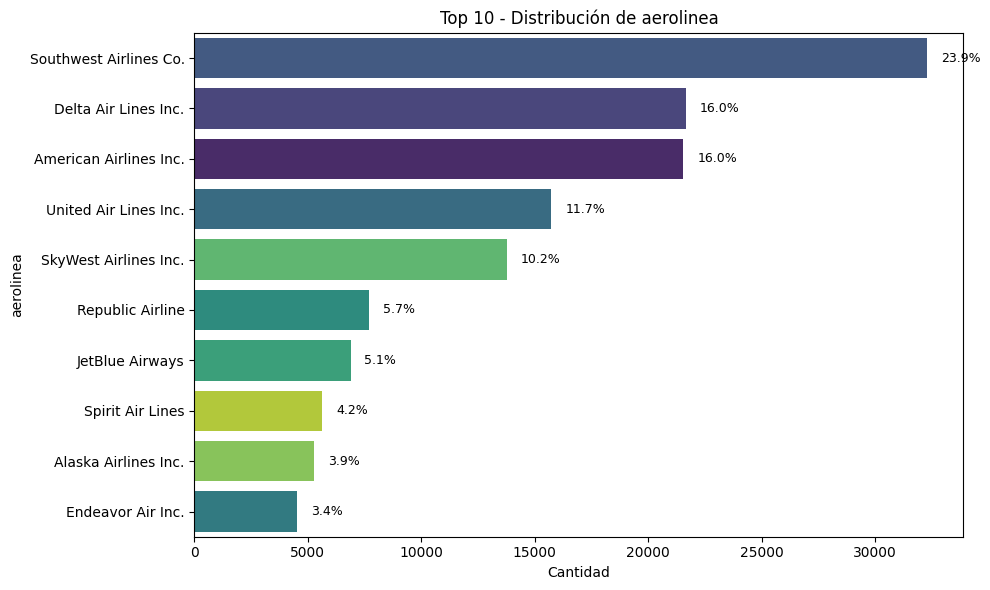

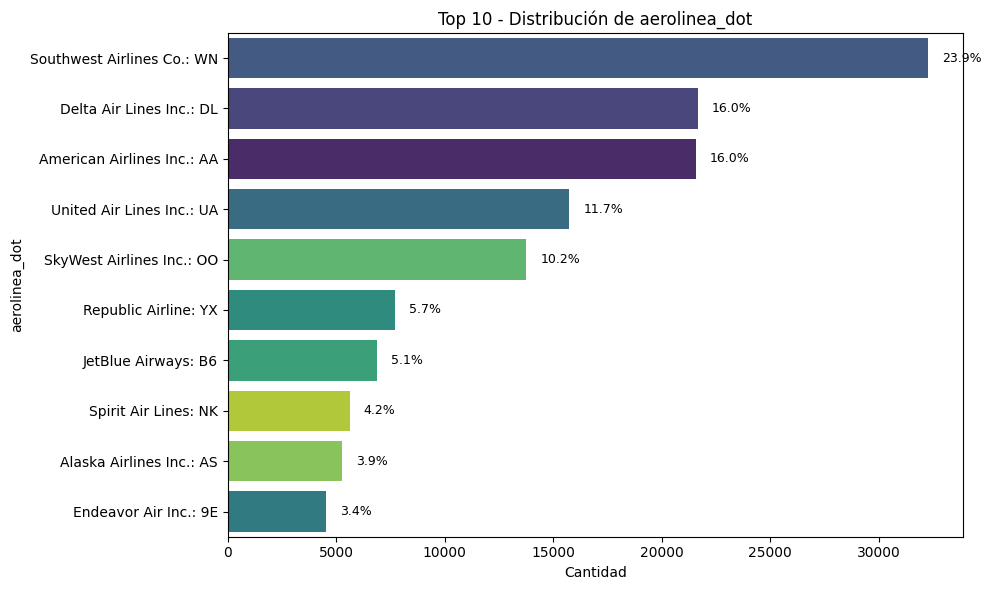

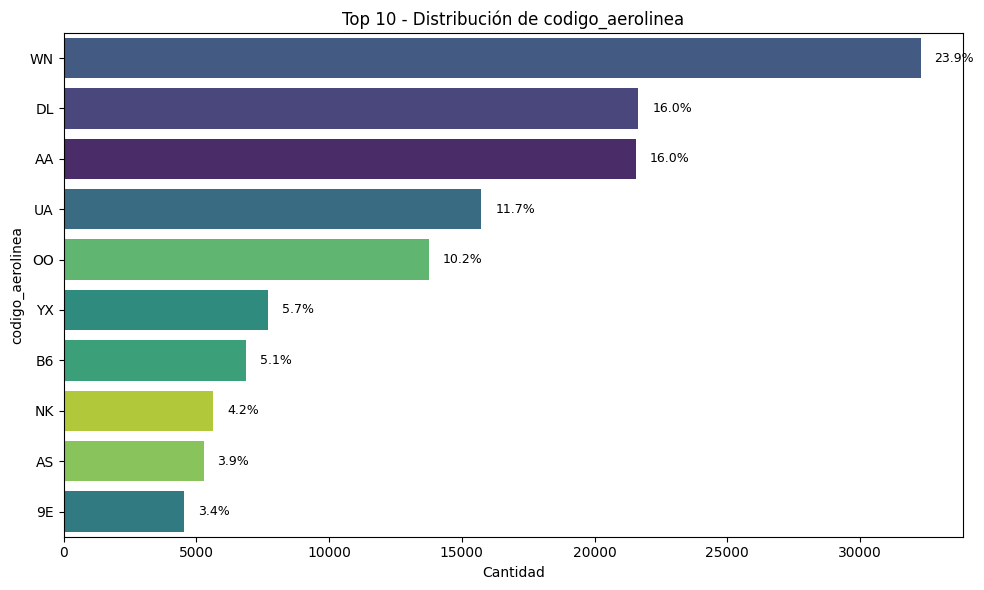

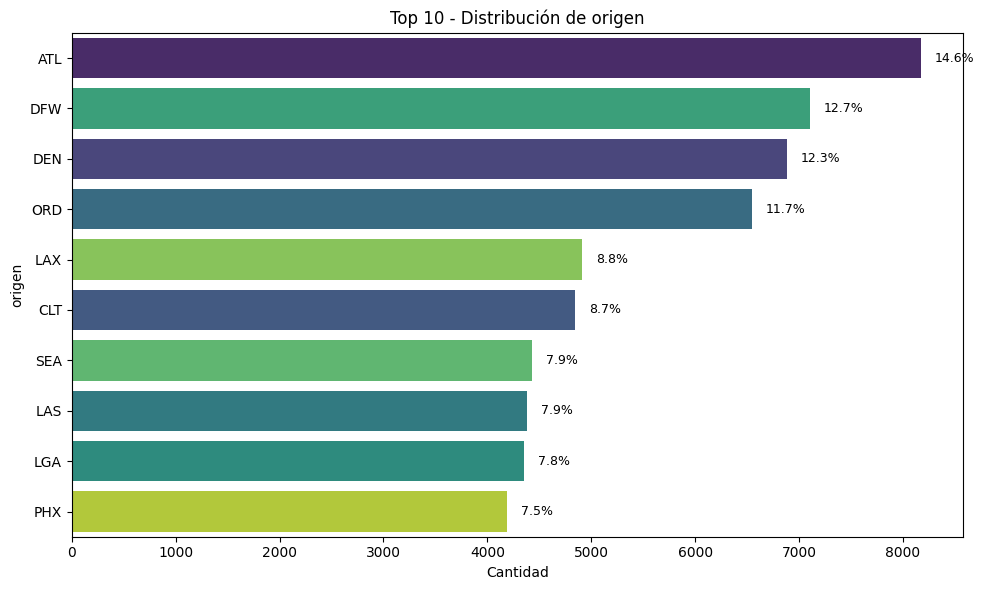

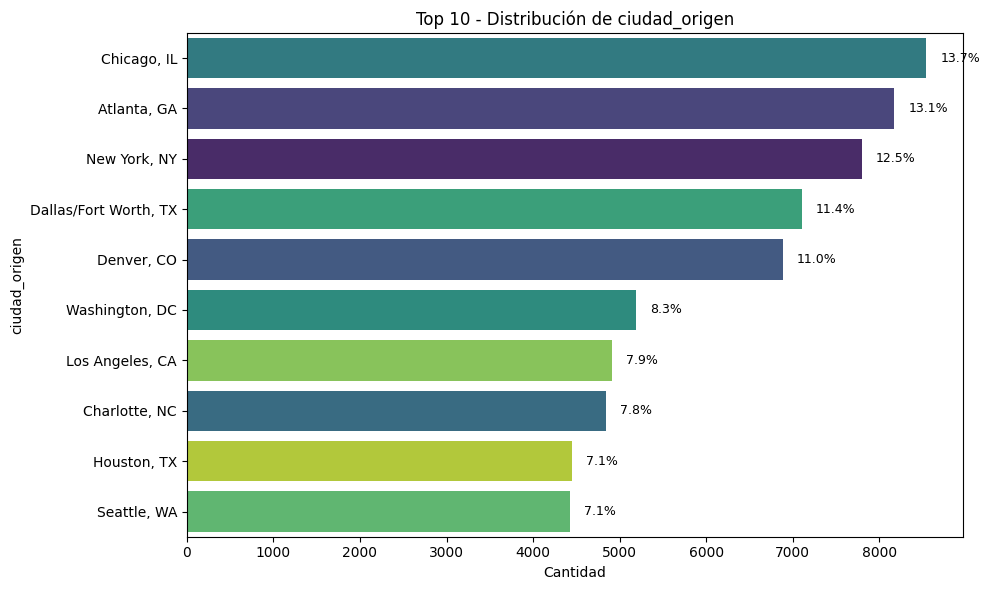

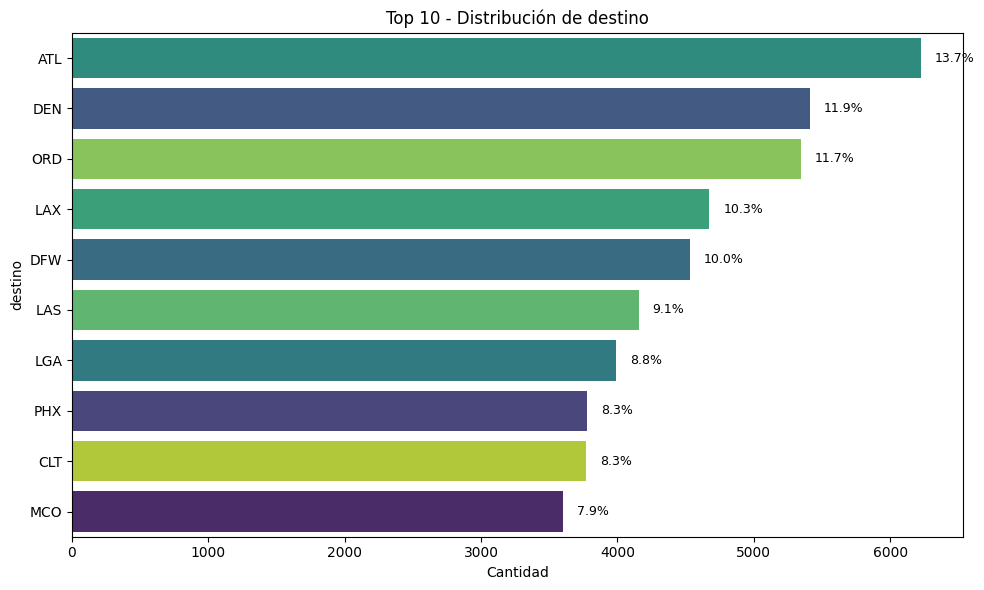

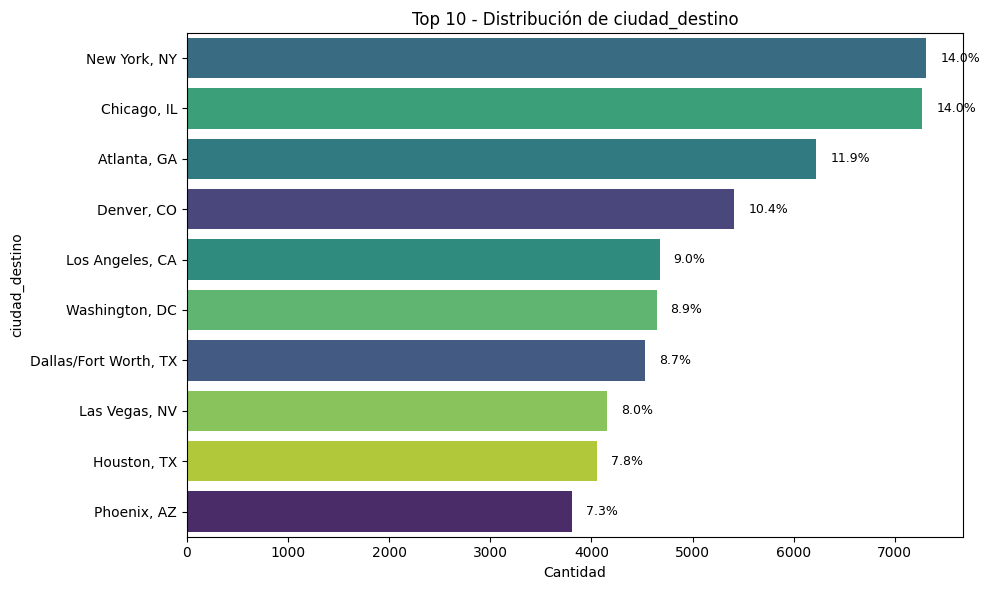

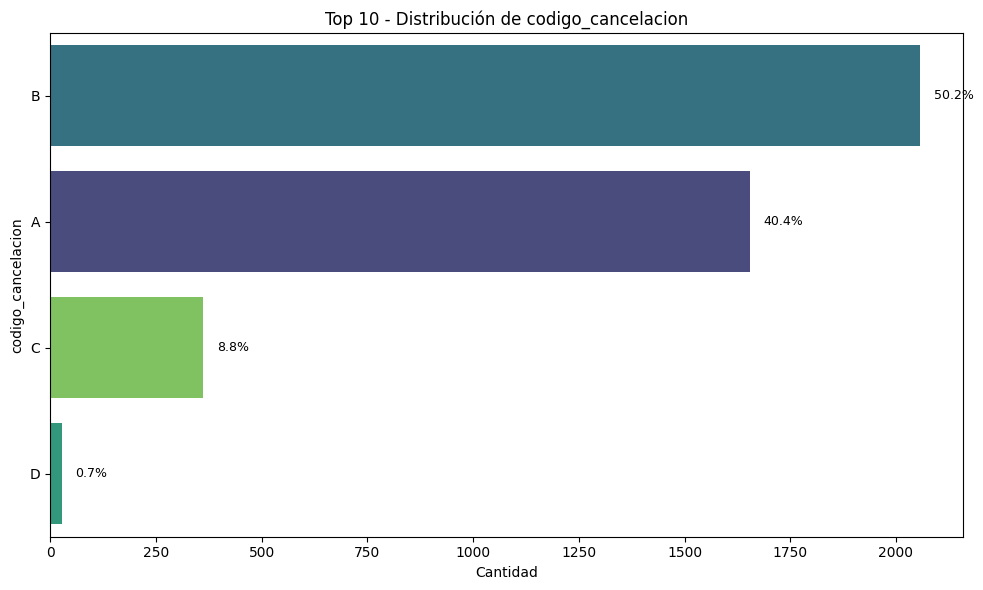

In [9]:
for col in categorical_columns:
    top10 = df_2022[col].value_counts().nlargest(10).index
    df_top10 = df_2022[df_2022[col].isin(top10)]

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_top10, y=col, hue=col, palette='viridis', legend=False, order=top10)
    plt.title(f'Top 10 - Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)

    total = len(df_top10)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y), ha='left', va='center', fontsize=9, color='black', xytext=(10, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()

Condición climática

La mayoría de los vuelos se registraron bajo condiciones de cielo mayormente nublado o despejado, mientras que las condiciones de con viento y lluevia representan una proción minoritaria, lo que nos da a entender que el clima adverso no es lo más usual.

mostly_cloudy: 32.7%
fair: 18.1%
cloudy: 17.9%

Por otro lado, existe una fuerte concnetración en pocos aeropuertos como LAX (Los Ángeles) con un 25%, seguido por SFO (San Francisco) con un 14% y luego BOS (Boston) con un 10.4%. Lo cual nos puede indicar que la mayoría de los vuelos son más para el Oeste de EEUU.

Por último, podemos ver que las aerolíneas con mayor cantidad de vuelos son JetBlue con un 33.3% y Delta con un 26.6% representan en conjunto un 60% de los vuelos.